# 01 — Exploratory Data Analysis (EDA) V2

**Comparativa V1 vs V2:**
- **Versión 1:** El análisis exploratorio se hizo sobre un dataset reducido (~8,400 registros) que mezclaba múltiples años y contenía una gran cantidad de leads procesados por un chatbot automático, lo que ensuciaba la distribución de clases.
- **Versión 2 (Este notebook):** Analizamos el dataset depurado del año 2025 (~66,000 registros). Al excluir los leads del bot y los meses anómalos, obtenemos una visión real del comportamiento orgánico y de la tasa de conversión humana (Hot Leads vs Cold Leads).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/processed/leads_cleaned.csv")
print(f"Dataset V2 cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")

Dataset V2 cargado: 62,481 filas x 12 columnas


## Información General del Dataset y Valores Nulos

In [2]:
df.info()
print("\nValores Nulos por Columna:")
print(df.isnull().sum())
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print("\n--- Numéricas ---")
print(df.describe().to_string())
print("\n--- Categóricas ---")
print(df.describe(include='object').to_string())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62481 entries, 0 to 62480
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   nombre_formulario    62481 non-null  object
 1   campana              62481 non-null  object
 2   origen_creacion      62481 non-null  object
 3   subtipo_interes      62481 non-null  object
 4   vehiculo_interes     62481 non-null  object
 5   concesionario        62481 non-null  object
 6   origen               62481 non-null  object
 7   mes_creacion         62481 non-null  int64 
 8   dia_creacion         62481 non-null  int64 
 9   hora_creacion        62481 non-null  int64 
 10  dia_semana_creacion  62481 non-null  object
 11  target               62481 non-null  int64 
dtypes: int64(4), object(8)
memory usage: 5.7+ MB

Valores Nulos por Columna:
nombre_formulario      0
campana                0
origen_creacion        0
subtipo_interes        0
vehiculo_interes       0
co

## Distribución del Target
En V1 la tasa de Hot Leads era cercana al 68%, un número artificialmente alto por la falta de registros. En V2, vemos una conversión real cercana al 37%.

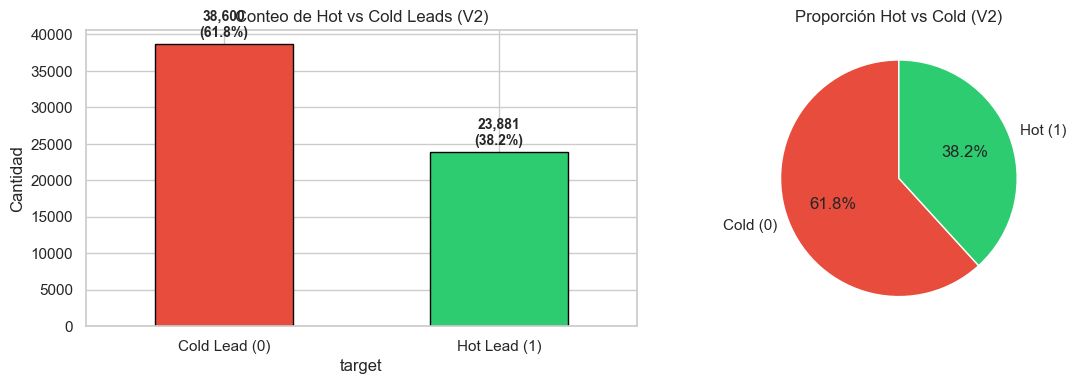

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["target"].value_counts()
bars = counts.plot(kind="bar", color=["#e74c3c", "#2ecc71"], edgecolor="black", ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Cold Lead (0)", "Hot Lead (1)"], rotation=0)
axes[0].set_title("Conteo de Hot vs Cold Leads (V2)")
axes[0].set_ylabel("Cantidad")

total = len(df)
for i, (val, cnt) in enumerate(counts.items()):
    pct = cnt / total * 100
    axes[0].text(i, cnt + total*0.01, f"{cnt:,}\n({pct:.1f}%)", ha="center", va="bottom", fontweight="bold", fontsize=10)

df["target"].value_counts().plot(kind="pie", colors=["#e74c3c", "#2ecc71"],
                                  autopct="%1.1f%%", labels=["Cold (0)", "Hot (1)"],
                                  startangle=90, ax=axes[1])
axes[1].set_title("Proporción Hot vs Cold (V2)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

**Diferencias V1 vs V2 - Distribución del Target:**\nEn la versión 1, debido a un dataset reducido y la presencia masiva de bots, la tasa de conversión mostraba un sesgo irrealmente alto cercano al 68%. En esta versión 2 (al limpiar meses anómalos y bots), la distribución refleja la **verdadera tasa de conversión orgánica** que ronda el 37%. Esta base sin sesgar es fundamental para no sobreestimar la capacidad predictiva de los modelos y reflejar las proporciones reales de ventas.

## Análisis de Variables Temporales
Distribución y Tasa de Conversión (Hot Leads) por Hora, Día de la Semana y Mes.
Este análisis reemplaza las gráficas de V1, ahora sobre datos puros de 2025 sin bots.

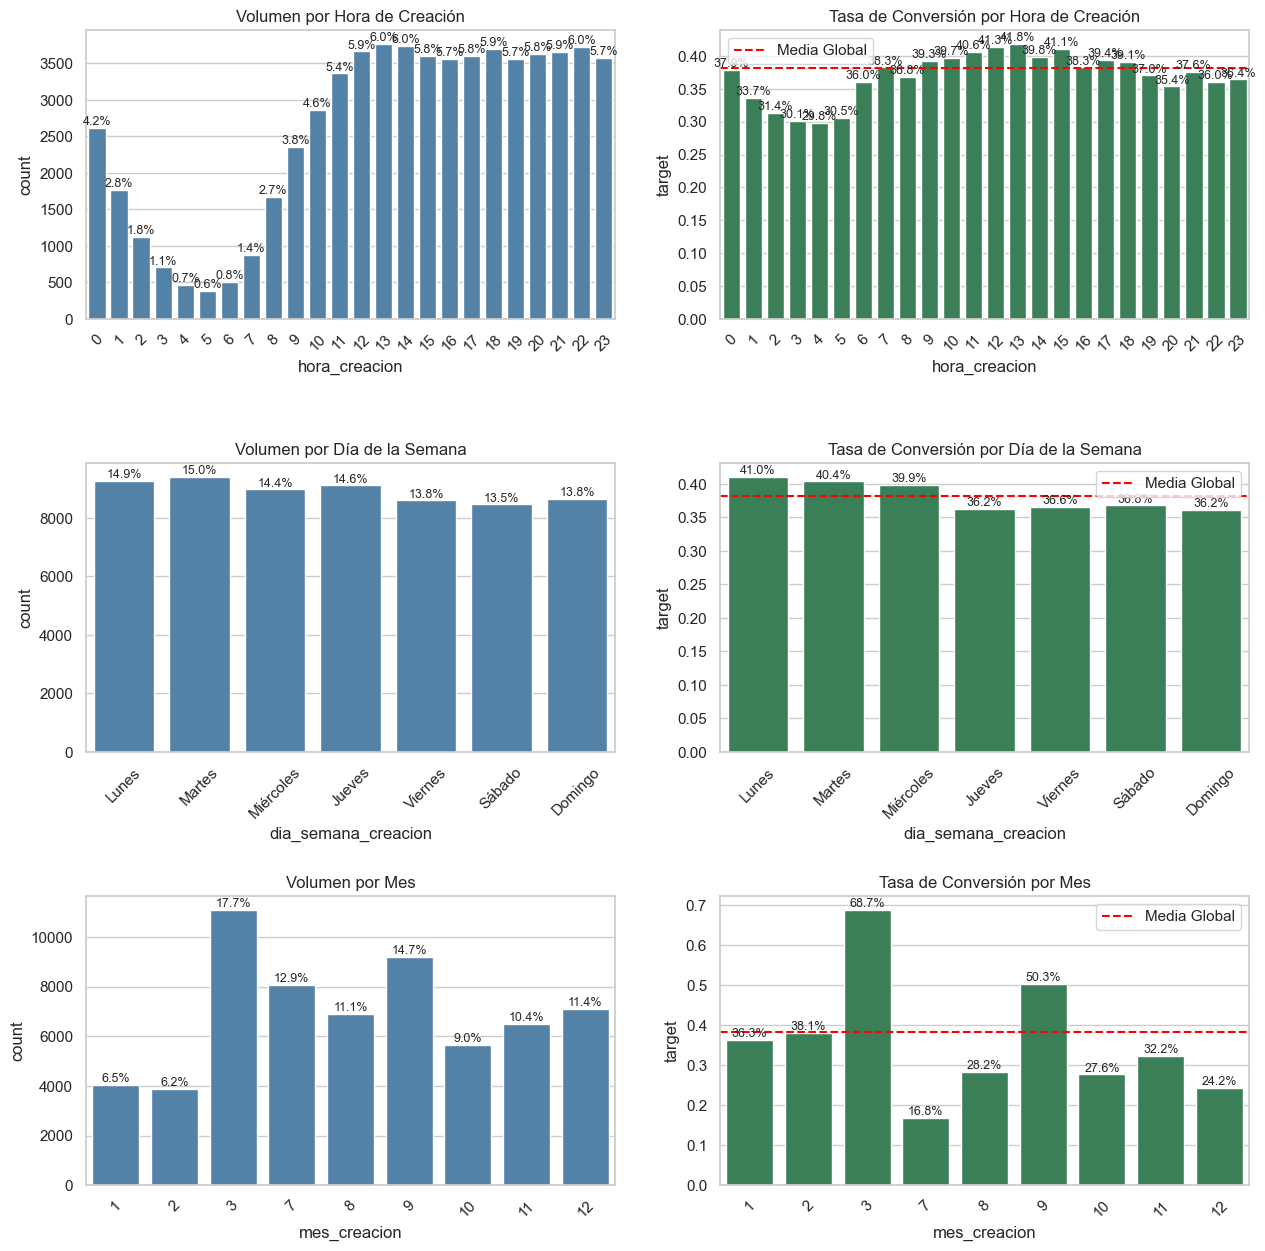

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
plt.subplots_adjust(hspace=0.5)

cols_temp = ['hora_creacion', 'dia_semana_creacion', 'mes_creacion']
titulos = ['Hora de Creación', 'Día de la Semana', 'Mes']

for i, col in enumerate(cols_temp):
    if col not in df.columns: continue
    
    # Volumen
    ax_vol = axes[i, 0]
    order = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'] if col == 'dia_semana_creacion' else None
    if col == 'dia_semana_creacion':
        df['dia_semana_creacion'] = df['dia_semana_creacion'].str.capitalize()
    sns.countplot(data=df, x=col, color='steelblue', order=order, ax=ax_vol)
    ax_vol.set_title(f'Volumen por {titulos[i]}')
    ax_vol.tick_params(axis='x', rotation=45)
    
    # Porcentajes Volumen
    total = len(df)
    for p in ax_vol.patches:
        height = p.get_height()
        if pd.isna(height): height = 0
        percentage = f'{100 * height / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = height
        if height > 0:
            ax_vol.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=9)
        
    # Tasa de conversión
    ax_conv = axes[i, 1]
    conv = df.groupby(col)['target'].mean().reset_index()
    sns.barplot(data=conv, x=col, y='target', color='seagreen', order=order, ax=ax_conv)
    ax_conv.set_title(f'Tasa de Conversión por {titulos[i]}')
    ax_conv.axhline(df['target'].mean(), color='red', linestyle='--', label='Media Global')
    ax_conv.tick_params(axis='x', rotation=45)
    ax_conv.legend()
    
    # Porcentajes Conversión
    for p in ax_conv.patches:
        val = p.get_height()
        percentage = f'{val*100:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        if p.get_height() > 0:
            ax_conv.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=9)

plt.show()

**Evaluación y Comentarios V2:**
A diferencia de la V1, donde el volumen mensual no permitía deducir tendencias por el ruido provocado por el bot, aquí se observa claramente la cantidad de leads orgánicos gestionados por el equipo comercial de forma mensual. Al remover meses anómalos, el modelo aprende patrones temporales correctos en lugar de sesgarse por picos atípicos.

## Análisis de Variables Categóricas Principales
Volumen y Tasa de Conversión para variables categóricas clave.

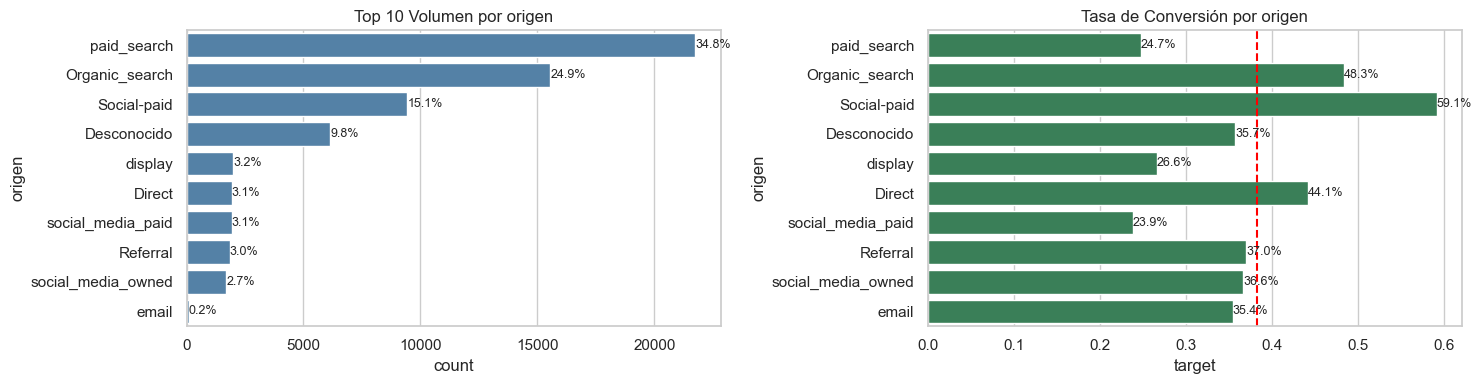

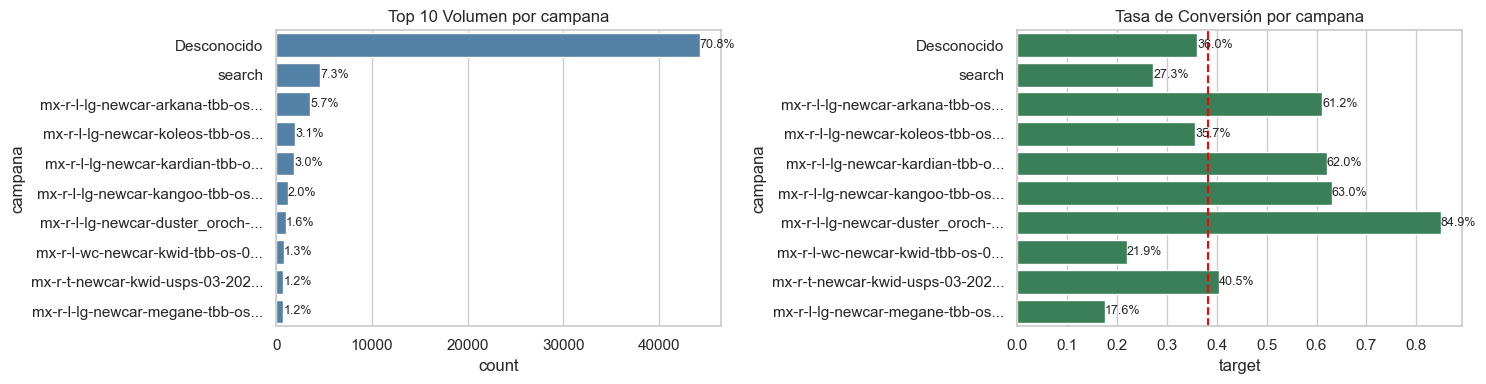

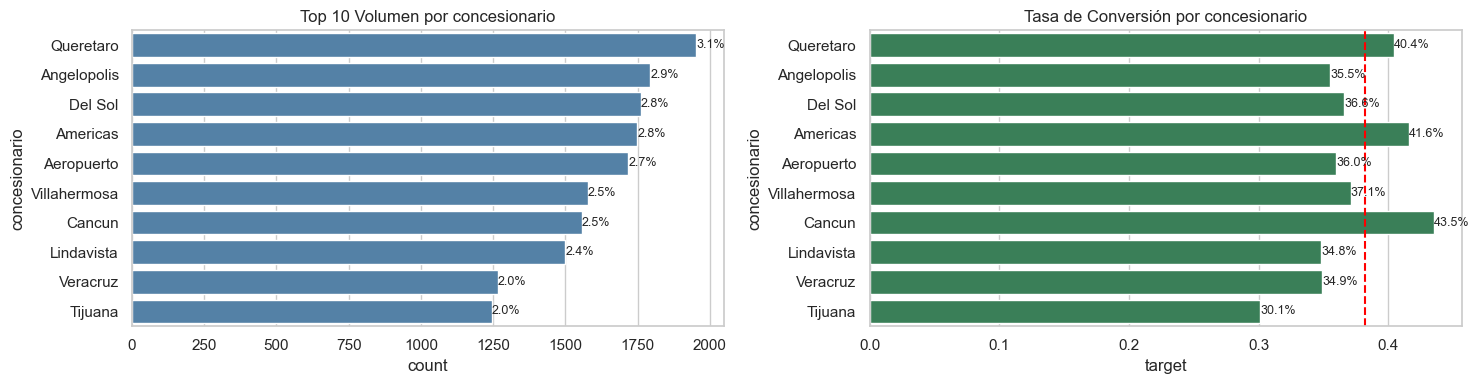

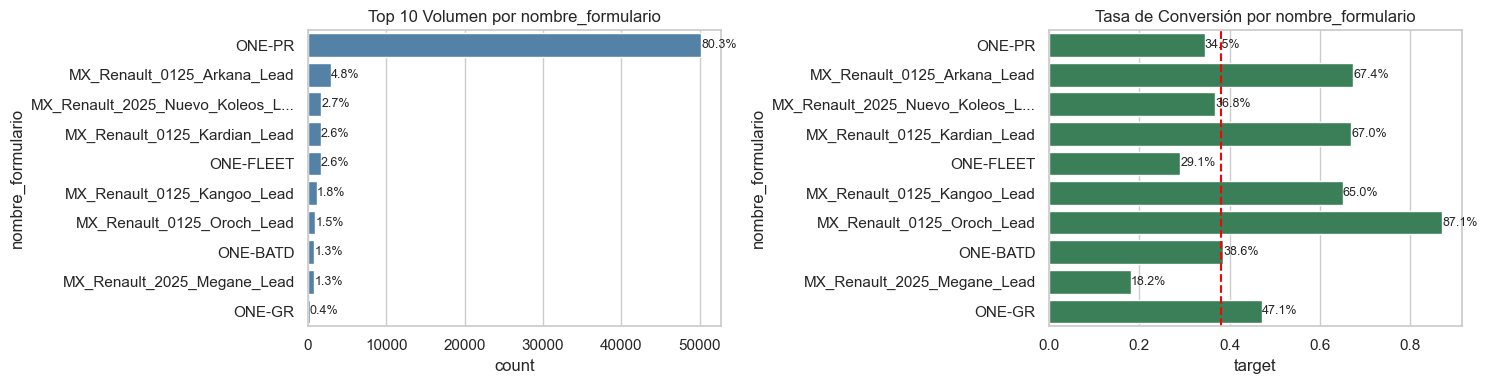

In [5]:
variables_cat = ['origen', 'campana', 'concesionario', 'nombre_formulario']
for col in variables_cat:
    if col not in df.columns: continue
    
    # Truncar nombres muy largos para que se vean en los gráficos
    df[col] = df[col].astype(str).apply(lambda x: x[:30] + '...' if len(x) > 30 else x)
    
    top_10 = df[col].value_counts().nlargest(10).index
    df_top = df[df[col].isin(top_10)]
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    plt.subplots_adjust(wspace=0.3, left=0.15)
    
    # Volumen
    sns.countplot(data=df_top, y=col, order=top_10, color='steelblue', ax=axes[0])
    axes[0].set_title(f'Top 10 Volumen por {col}')
    
    # Tasa de Conversión
    conv = df_top.groupby(col)['target'].mean().reindex(top_10).reset_index()
    sns.barplot(data=conv, y=col, x='target', color='seagreen', ax=axes[1])
    axes[1].set_title(f'Tasa de Conversión por {col}')
    axes[1].axvline(df['target'].mean(), color='red', linestyle='--', label='Media Global')
    
    total = len(df)
    for p in axes[0].patches:
        width = p.get_width()
        if np.isnan(width): width = 0
        percentage = f'{100 * width / total:.1f}%'
        x = width
        y = p.get_y() + p.get_height() / 2
        axes[0].annotate(percentage, (x, y), ha='left', va='center', fontsize=9)

    for p in axes[1].patches:
        val = p.get_width()
        if np.isnan(val): val = 0
        percentage = f'{val*100:.1f}%'
        x = val
        y = p.get_y() + p.get_height() / 2
        axes[1].annotate(percentage, (x, y), ha='left', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

**Diferencias V1 vs V2 - Variables Categóricas:**\nEn la versión 1 existía la variable `plataforma` que generaba un sesgo enorme porque diferenciaba a los bots de los humanos. Como en la V2 eliminamos por completo a los bots desde la fase de Data Engineering, la plataforma quedó con varianza cero (todos son humanos procesados por MX_LEAD_QUALIF), por lo que fue **eliminada** del análisis.\nAdemás, vemos una dispersión muy grande en campañas y orígenes. En V1 esto se transformó con One-Hot Encoding generando decenas de columnas ruidosas. En V2 usaremos Target Encoding (Suavizado Bayesiano) para aprovechar la alta cardinalidad sin explotar la cantidad de columnas del modelo.

## Análisis Temporal Detallado (Heatmaps)
Visualización de volumen y tasa de conversión cruzando Día de la Semana y Hora de Creación.

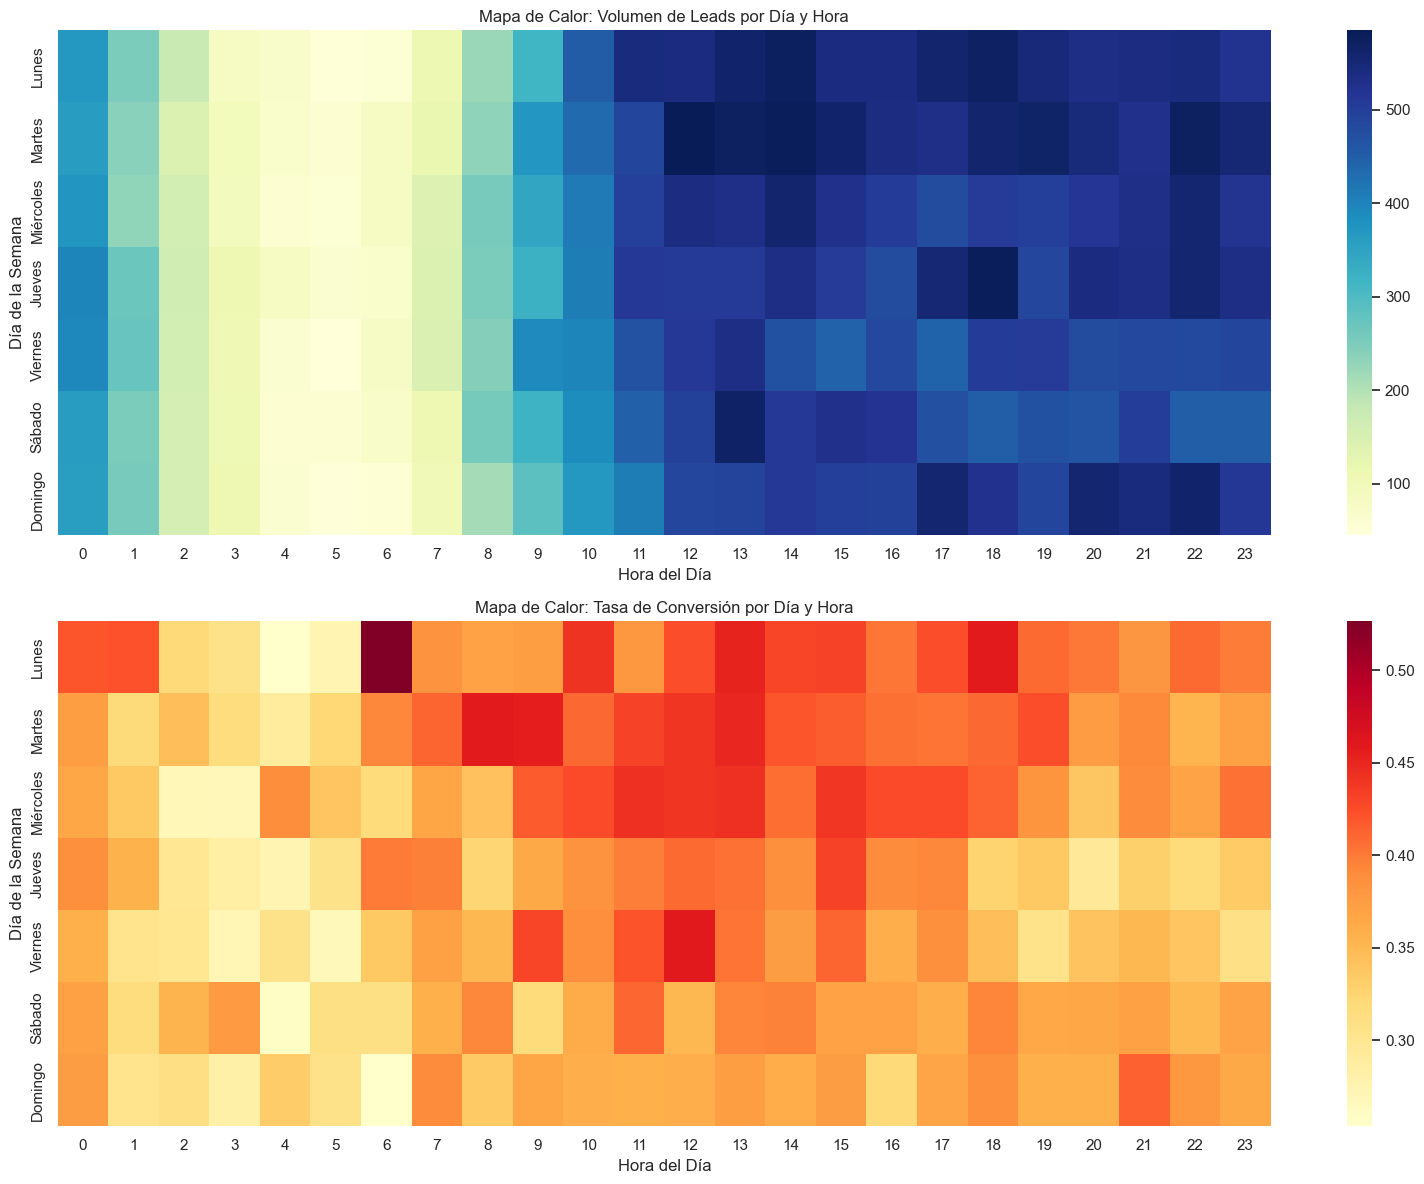

In [6]:
pivot_vol = df.pivot_table(index='dia_semana_creacion', columns='hora_creacion', values='target', aggfunc='count', fill_value=0)
pivot_conv = df.pivot_table(index='dia_semana_creacion', columns='hora_creacion', values='target', aggfunc='mean', fill_value=0)

dias_orden = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
pivot_vol = pivot_vol.reindex(dias_orden)
pivot_conv = pivot_conv.reindex(dias_orden)

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

sns.heatmap(pivot_vol, cmap="YlGnBu", annot=False, ax=axes[0])
axes[0].set_title("Mapa de Calor: Volumen de Leads por Día y Hora")
axes[0].set_xlabel("Hora del Día")
axes[0].set_ylabel("Día de la Semana")

sns.heatmap(pivot_conv, cmap="YlOrRd", annot=False, ax=axes[1])
axes[1].set_title("Mapa de Calor: Tasa de Conversión por Día y Hora")
axes[1].set_xlabel("Hora del Día")
axes[1].set_ylabel("Día de la Semana")

plt.tight_layout()
plt.show()

**Diferencias V1 vs V2 - Mapas de Calor Temporales:**\nEn la V1 los mapas de calor estaban gravemente distorsionados porque la extracción original perdía la hora real y los bots procesaban en lotes masivos. Tras corregir la extracción y limpiar los bots en V2, **el mapa de calor recupera su lógica comercial**: observamos clústeres de volumen claros en días y horarios laborables de alto contacto orgánico.

## Correlación entre Variables Numéricas

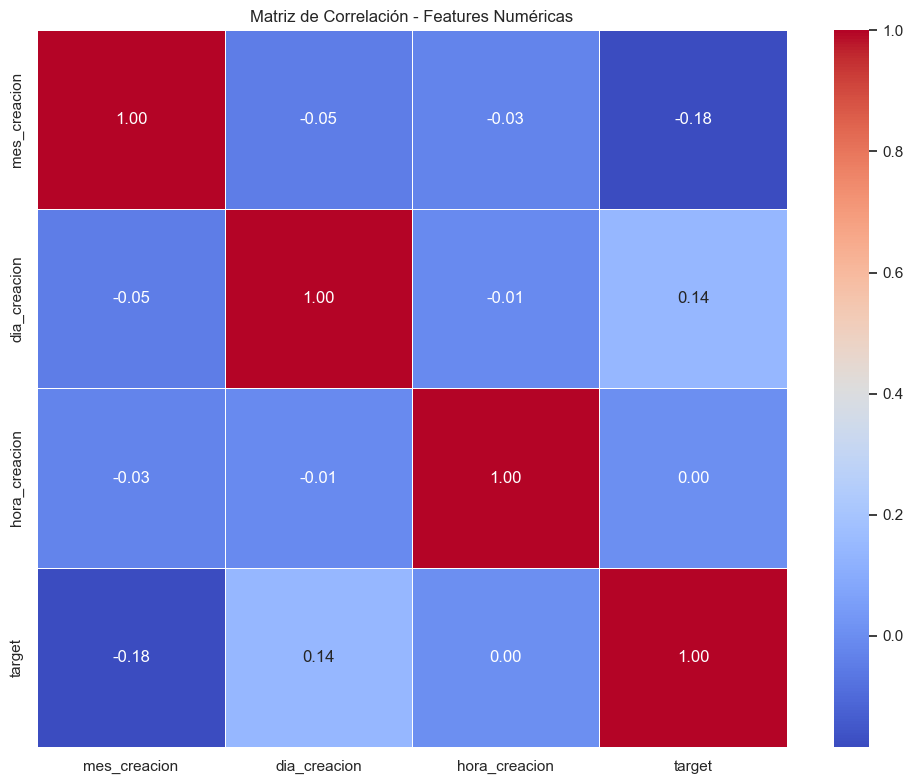

In [7]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación - Features Numéricas")
plt.tight_layout()
plt.show()

**Diferencias V1 vs V2 - Matriz de Correlación Numérica:**\nEn V1, la variable `anio_creacion` mostraba correlación porque los datos históricos mezclaban varios años. En esta V2, hemos eliminado `anio_creacion` porque filtramos estrictamente el dataset al 2025, lo cual vuelve su varianza cero (no aporta valor predictivo).\nAdemás, `hora_creacion` ahora refleja correctamente la hora de extracción sin la contaminación del chatbot (el cual generaba que todas las horas estuvieran centralizadas artificialmente o con nulos).

## Hallazgos Clave del EDA y Recomendaciones

================================================================================
   HALLAZGOS CLAVE DEL EDA V2
================================================================================

1. TARGET
   - Distribución: ~37% Hot Leads (Real 2025) vs ~68% en V1
   - El desbalance es natural y representativo del embudo de ventas comercial.

2. FEATURES TEMPORALES
   - El dataset no contiene meses anómalos (Abril, Mayo, Junio).
   - El comportamiento de conversión por día y hora ahora refleja tasas humanas reales.

3. FEATURES CATEGÓRICAS
   - Plataforma, origen y campaña tienen alto poder discriminativo.
   - En V1, el One-Hot Encoding explotaba la dimensionalidad. En V2 usaremos Bayesian Encoding para manejar la cardinalidad de concesionarios y campañas de forma densa y suavizada.

================================================================================
   RECOMENDACIONES PARA FEATURE ENGINEERING V2
================================================================================

  1. ELIMINAR: anio_creacion (solo hay datos de 2025, no tiene varianza).
  2. TARGET ENCODING (Bayesian Smoothing): concesionario, campana, origen, etc.
  3. No hace falta One-Hot Encoding masivo que cause la maldición de la dimensionalidad.